# Comparative Analysis of BNNs on PovertyMap (WILDS)

## 1. Introduction and Theoretical Background
In this project, we compare two distinct approaches to estimating epistemic and aleatoric uncertainty in Bayesian Neural Networks (BNNs) on the PovertyMap dataset from the WILDS benchmark. This task involves predicting the asset wealth index from satellite imagery using a ResNet-18 architecture, and evaluating in-distribution (ID) versus out-of-distribution (OOD) generalization across different country folds.


Through multi-fold validation (Folds A-E), this notebook structurally compiles theoretical capabilities, training/inference time overheads, RMSE, Negative Log-Likelihood (NLL), and Calibration Error to benchmark these Bayesian approaches.

In [1]:
from pathlib import Path
import sys, os, time, copy, json, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import resnet18
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import norm
from laplace import Laplace
from bayesian_torch.models.dnn_to_bnn import dnn_to_bnn, get_kl_loss
from wilds import get_dataset

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "shared").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from shared import (
    checkpoint_exists, load_checkpoint, save_checkpoint, seed_everything,
    regression_metrics, regression_uncertainty_stats,
)

SEED = 42
seed_everything(SEED)

WILDS_ROOT = str(ROOT / "data" / "wilds")
os.makedirs(WILDS_ROOT, exist_ok=True)
CHECKPOINT_BASE = str(ROOT / "notebooks" / "comparison" / "results" / "checkpoints" / "bnn_comparison_povertymap")
os.makedirs(CHECKPOINT_BASE, exist_ok=True)
FIGURES_DIR = str(ROOT / "notebooks" / "comparison" / "results" / "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

metrics_dict = {
    "MAP": defaultdict(list),
    "Laplace": defaultdict(list),
    "Bayesian-Torch": defaultdict(list),
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
warnings.filterwarnings("ignore")
plt.rcParams.update({"font.family": "serif", "font.size": 12,
                     "savefig.dpi": 150, "savefig.bbox": "tight"})
print(f"PovertyMap BNN comparison | seed={SEED} | device={device} | checkpoints -> {CHECKPOINT_BASE}")

/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


PovertyMap BNN comparison | seed=42 | device=cuda | checkpoints -> /u/halle/carg/home_at/Documents/BNNs/notebooks/comparison/results/checkpoints/bnn_comparison_povertymap


## 2. Load PovertyMap Dataset (WILDS Official)

Loads the official PovertyMap dataset from the WILDS benchmark. Satellite images (224×224, 8 multi-spectral bands, already mean/std normalized) with target `wealthpooled` (asset wealth index).

WILDS splits (by country):
- `train`: 5 countries in-distribution
- `id_val`: ID validation (subset)
- `id_test`: ID test (subset)
- `val`: OOD validation (held-out country)
- `test`: OOD test (held-out countries)

Folds A-E correspond to 5 different country splits (used as seeds per paper).

In [2]:
WILDS_ROOT = str(ROOT / "data" / "wilds")
os.makedirs(WILDS_ROOT, exist_ok=True)

print("Loading PovertyMap from WILDS...")
dataset = get_dataset(dataset='poverty', download=False, root_dir=WILDS_ROOT)
print(f"Dataset loaded. Total samples: {len(dataset)}")
print(f"Splits: {dataset.split_names}")

Loading PovertyMap from WILDS...
Dataset loaded. Total samples: 19669
Splits: {'train': 'Train', 'id_val': 'ID Val', 'id_test': 'ID Test', 'val': 'OOD Val', 'test': 'OOD Test'}


In [3]:
def poverty_transform(img):
    """Convert the dataset image to float tensor."""
    return img.float()

def get_dataloaders(dataset, batch_size=64):
    """Get train/val/test loaders for the given fold dataset."""
    loaders = {}
    for split_name in ['train', 'id_val', 'id_test', 'val', 'test']:
        split_data = dataset.get_subset(split_name, transform=poverty_transform, frac=1.0)
        loaders[split_name] = DataLoader(
            split_data, batch_size=batch_size, shuffle=(split_name == 'train'),
            num_workers=16, pin_memory=True,
        )
    return loaders

# Quick sanity check on the default (fold A) dataset
test_loaders = get_dataloaders(dataset, batch_size=4)
for X, y, meta in test_loaders['train']:
    print(f"Image batch shape: {X.shape}  (expected: [batch, 8, 224, 224])")
    print(f"Target batch shape: {y.shape}  (expected: [batch, 1])")
    print(f"Metadata shape: {meta.shape}")
    print(f"Target range: [{y.min().item():.4f}, {y.max().item():.4f}]")
    break

Image batch shape: torch.Size([4, 8, 224, 224])  (expected: [batch, 8, 224, 224])
Target batch shape: torch.Size([4, 1])  (expected: [batch, 1])
Metadata shape: torch.Size([4, 4])
Target range: [-0.5755, 1.1394]


## 3. Model: ResNet-18 for Multi-Spectral Satellite Imagery

ResNet-18 adapted for 8-channel inputs. Matches the architecture used in Daxberger et al. (2021) and the WILDS benchmark. First conv layer adapted from 3→8 channels, final FC layer replaced with single-output regression head.

In [4]:
class PovertyResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = resnet18(weights=None)
        # Adapt first conv from 3 -> 8 channels
        self.backbone.conv1 = nn.Conv2d(8, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # Replace final FC layer with single-output regression head
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.backbone(x)

def create_model(seed=42):
    torch.manual_seed(seed)
    return PovertyResNet()

model = create_model()
n_params = sum(p.numel() for p in model.parameters())
print(f"Model: ResNet-18, total params: {n_params:,}")

Model: ResNet-18, total params: 11,192,705


In [5]:
def train_map(model, train_loader, val_loader, n_epochs=50, lr=1e-3, verbose=True, checkpoint_path=None):
    if checkpoint_exists(checkpoint_path):
        checkpoint = load_checkpoint(checkpoint_path, map_location='cpu')
        model.load_state_dict(checkpoint['model_state_dict'])
        history = checkpoint.get('history', {'train_loss': [], 'val_loss': []})
        if verbose:
            print(f'Loaded MAP checkpoint: {checkpoint_path}')
        return model.to(device), history

    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(n_epochs):
        model.train()
        train_loss = 0.0
        for X, y, _ in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y, _ in val_loader:
                X, y = X.to(device), y.to(device)
                loss = criterion(model(X), y)
                val_loss += loss.item()
        val_loss /= len(val_loader)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 20:
                if verbose: print(f'  Early stopping at epoch {epoch+1}')
                break

        if verbose and (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1}/{n_epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

    model.load_state_dict(best_state)
    if verbose: print(f'MAP complete. Best val loss: {best_val_loss:.6f}')

    if checkpoint_path:
        save_checkpoint(
            {
                'model_state_dict': model.state_dict(),
                'history': history,
                'seed': SEED,
                'n_epochs': n_epochs,
                'lr': lr,
            },
            checkpoint_path,
        )
    return model, history

## 5. Laplace Approximation (Full Last-Layer + GLM Predictive)

Following Daxberger et al. (2021):
- Full covariance over last layer (ResNet-18 last layer is 512×1 — small enough for full Hessian)
- Hyperparameters (prior precision, noise sigma) tuned by minimizing NLL on ID validation set
- GLM predictive with 2,000 samples

In [ ]:
def train_laplace(map_model, train_loader, val_loader, checkpoint_path=None):
    """
    Fit full last-layer Laplace, tune prior precision and noise sigma
    via grid search on ID validation NLL (Daxberger et al. 2021, Appendix C.3).

    Saves la.state_dict() (H, mean, prior_precision, sigma_noise, data batch).
    On load, la.fit() is skipped entirely — load_state_dict restores H and sets
    up the FeatureExtractor from the saved data batch internally.
    """
    model_la = create_model()
    model_la.load_state_dict(map_model.state_dict())
    model_la = model_la.to(device)

    la = Laplace(model_la, likelihood="regression",
                 subset_of_weights="last_layer", hessian_structure="full")

    # WILDS loaders yield (X, y, metadata) triplets; Laplace expects (X, y) pairs
    class DropMetadataLoader:
        def __init__(self, loader):
            self.loader = loader
        @property
        def dataset(self):
            return self.loader.dataset
        def __iter__(self):
            for X, y, _ in self.loader:
                yield X, y
        def __len__(self):
            return len(self.loader)
        def __getattr__(self, name):
            return getattr(self.loader, name)

    train_loader_la = DropMetadataLoader(train_loader)
    val_loader_la   = DropMetadataLoader(val_loader)

    if checkpoint_path and os.path.isfile(checkpoint_path):
        ck = torch.load(checkpoint_path, map_location=device)
        if 'la_state_dict' in ck:
            la.load_state_dict(ck['la_state_dict'])
            print(f'  Loaded Laplace: prior_prec={float(la.prior_precision):.4f}, '
                  f'sigma_noise={la.sigma_noise.item():.4f}')
            return la, model_la

    la.fit(train_loader_la)

    # Step 1: grid search over prior_precision minimising val NLL 
    la.optimize_prior_precision(
        method='gridsearch',
        val_loader=val_loader_la,
        pred_type='glm',
    )

    # Step 2: grid search over sigma_noise with fixed prior_precision
    sigma_grid = np.logspace(-2, 1, 30)
    best_nll, best_sigma = float('inf'), 1.0
    with torch.no_grad():
        for sigma in sigma_grid:
            la.sigma_noise = torch.tensor(sigma, device=device)
            nll_total, n_total = 0.0, 0
            for X, y in val_loader_la:
                X = X.to(device)
                f_mu, f_var = la(X, pred_type='glm', n_samples=N_MC_LAPLACE)
                pred_std = (f_var.squeeze() + sigma ** 2).sqrt().clamp(min=1e-6)
                resid = y.squeeze().to(device) - f_mu.squeeze()
                nll_total += (0.5 * np.log(2 * np.pi)
                              + pred_std.log()
                              + 0.5 * (resid / pred_std) ** 2).sum().item()
                n_total += y.size(0)
            avg_nll = nll_total / n_total
            if avg_nll < best_nll:
                best_nll, best_sigma = avg_nll, sigma
    la.sigma_noise = torch.tensor(best_sigma, device=device)

    print(f'  Gridsearch: prior_prec={float(la.prior_precision):.4f}, '
          f'sigma_noise={la.sigma_noise.item():.4f}, val_nll={best_nll:.4f}')

    if checkpoint_path:
        torch.save({'la_state_dict': la.state_dict()}, checkpoint_path)

    return la, model_la


def predict_laplace(la, loader, n_samples=2000):
    """Predict using Laplace GLM posterior."""
    la.model.eval()
    all_mu, all_std, all_y = [], [], []
    with torch.no_grad():
        for X, y, _ in loader:
            X = X.to(device)
            f_mu, f_var = la(X, pred_type='glm', n_samples=n_samples)
            sigma_noise = la.sigma_noise.item() if la.sigma_noise is not None else 0.0
            pred_std = (f_var.squeeze() + sigma_noise ** 2).sqrt().clamp(min=1e-6)
            all_mu.append(f_mu.squeeze().cpu())
            all_std.append(pred_std.cpu())
            all_y.append(y.squeeze())
    return torch.cat(all_mu).numpy(), torch.cat(all_std).numpy(), torch.cat(all_y).numpy()

## 6. Bayesian-Torch (Flipout + SVI)

Variational Bayes baseline using Bayesian-Torch, following Daxberger et al. (2021):
- Diagonal Gaussian posterior with Flipout estimator
- Prior precision = 5×10⁻⁴ (matching MAP weight_decay=1e-4, i.e. prior_sigma = 1/√(5×10⁻⁴) ≈ 44.72)
- KL downscaling factor = 0.1, following [13] in the paper
- Trained from random initialization (no MOPED)

In [7]:
def train_bayesian_torch(map_model, train_loader, val_loader, n_epochs=25, lr=1e-3, verbose=True, checkpoint_path=None):
    bnn_params = {
        "prior_mu": 0.0, "prior_sigma": (1.0 / 5e-4) ** 0.5,  # =1/sqrt(5e-4)≈44.72, matches prior_precision=5e-4
        "posterior_mu_init": 0.0, "posterior_rho_init": -3.0,
        "type": "Flipout", "moped_enable": False,
    }

    if checkpoint_exists(checkpoint_path):
        checkpoint = load_checkpoint(checkpoint_path, map_location='cpu')
        model_bnn = create_model().cpu()
        dnn_to_bnn(model_bnn, bnn_params)
        model_bnn.load_state_dict(checkpoint['model_state_dict'])
        history = checkpoint.get('history', {'elbo_loss': [], 'kl_loss': [], 'val_loss': []})
        if verbose:
            print(f'Loaded BNN checkpoint: {checkpoint_path}')
        return model_bnn.to(device), history

    # Train from random init (no MOPED) — paper §C, prior_precision=5e-4, KL factor=0.1
    model_bnn = create_model().cpu()
    dnn_to_bnn(model_bnn, bnn_params)
    model_bnn = model_bnn.to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model_bnn.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )

    history = {'elbo_loss': [], 'kl_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(n_epochs):
        model_bnn.train()
        epoch_elbo, epoch_kl = 0.0, 0.0
        for X, y, _ in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            output = model_bnn(X)
            kl = get_kl_loss(model_bnn)
            mse = criterion(output, y)
            loss = mse + 0.1 * kl
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_bnn.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_elbo += loss.item()
            epoch_kl += kl.item()
        epoch_elbo /= len(train_loader)
        epoch_kl /= len(train_loader)

        model_bnn.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y, _ in val_loader:
                X, y = X.to(device), y.to(device)
                val_loss += criterion(model_bnn(X), y).item()
        val_loss /= len(val_loader)

        history['elbo_loss'].append(epoch_elbo)
        history['kl_loss'].append(epoch_kl)
        history['val_loss'].append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model_bnn.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 20:
                if verbose: print(f'  Early stopping at epoch {epoch+1}')
                break

        if verbose and (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1}/{n_epochs}, ELBO: {epoch_elbo:.4f}, '
                  f'KL: {epoch_kl:.4f}, Val MSE: {val_loss:.6f}')

    model_bnn.load_state_dict(best_state)
    if verbose: print(f'BNN complete. Best val loss: {best_val_loss:.6f}')

    if checkpoint_path:
        save_checkpoint(
            {
                'model_state_dict': model_bnn.state_dict(),
                'history': history,
                'seed': SEED,
                'n_epochs': n_epochs,
                'lr': lr,
            },
            checkpoint_path,
        )
    return model_bnn, history

In [8]:
def predict_bayesian_torch(model_bnn, loader, n_mc=50):
    """MC-sample predictions from a Bayesian-Torch model on a WILDS loader.

    Returns (mean, std, targets) all as numpy arrays, where std is the
    predictive std (epistemic from MC variance + fixed sigma_noise ignored here —
    total std = MC std used as total for NLL).
    """
    model_bnn.eval()
    all_mu, all_std, all_y = [], [], []
    with torch.no_grad():
        for X, y, _ in loader:
            X = X.to(device)
            samples = torch.stack([model_bnn(X).squeeze(-1) for _ in range(n_mc)])  # (MC, B)
            mu  = samples.mean(0)
            std = samples.std(0).clamp(min=1e-6)
            all_mu.append(mu.cpu())
            all_std.append(std.cpu())
            all_y.append(y.squeeze())
    return torch.cat(all_mu).numpy(), torch.cat(all_std).numpy(), torch.cat(all_y).numpy()

## 7. Evaluation Metrics

Following Daxberger et al. (2021): MSE, NLL, and Regression Calibration Error (Kuleshov et al. 2018).

In [9]:
# Canonical regression metrics come from shared.regression_metrics (same formula across all notebooks).
# Scalar helpers below match that formula and remain for backward compat with print_results.

def compute_mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def compute_rmse(y_true, y_pred):
    return float(np.sqrt(compute_mse(y_true, y_pred)))

def compute_nll(y_true, y_pred_mean, y_pred_std):
    """Gaussian NLL — identical to shared.regression_metrics['NLL']."""
    resid = y_true - y_pred_mean
    return float(np.mean(0.5 * np.log(2 * np.pi * y_pred_std ** 2) + resid ** 2 / (2 * y_pred_std ** 2)))

def compute_regression_cal_error(y_true, y_pred_mean, y_pred_std, n_bins=20):
    """Symmetric two-sided interval coverage MAE (z-score based). Related to but
    NOT numerically equivalent to Kuleshov et al. (2018)'s primary one-sided Eq. 3
    definition (see compute_kuleshov_calibration below), since this discards the
    sign of residuals while the one-sided version does not.
    """
    z = np.abs(y_true - y_pred_mean) / y_pred_std
    conf = np.linspace(0.05, 0.95, n_bins)
    obs = [np.mean(z <= norm.ppf((1 + c) / 2)) for c in conf]
    return float(np.mean(np.abs(np.array(obs) - conf)))


def compute_kuleshov_calibration(y_true, y_pred_mean, y_pred_std, M=10):
    """Kuleshov et al. (2018) Eq. 3 one-sided regression calibration error —
    matches Laplace Redux's get_calib_regression exactly: cal = T * MSE(p, p_hat),
    where p_hat(p) = fraction of points with predictive-CDF(y) <= p, scanned over
    p in [0, 1]. This is the specific formula Laplace Redux plots as "regression
    calibration error" for PovertyMap (Fig. 6/10).
    """
    T = len(y_true)
    ps = np.linspace(0, 1, M)
    cdf_vals = norm.cdf(y_true, loc=y_pred_mean, scale=y_pred_std)
    p_hats = np.array([np.mean(cdf_vals <= p) for p in ps])
    return float(T * np.mean((ps - p_hats) ** 2))

def print_results(results, seeds):
    print("\n" + "=" * 100)
    print(f"POVERTYMAP BNN COMPARISON ({len(seeds)} seeds) — Following Laplace Redux (2021)")
    print("=" * 100)
    for split_name in ['id_test', 'test']:
        label = 'IN-DISTRIBUTION (ID)' if split_name == 'id_test' else 'OUT-OF-DISTRIBUTION (OOD)'
        print(f"\n{'─'*80}\n  {label}\n{'─'*80}")
        print(f"{'Method':20s} {'RMSE':16s} {'NLL':16s} {'Cal_MAE':16s} {'Coverage_95':14s}")
        print(f"{'─'*80}")
        for method, mname in [('map', 'MAP'), ('laplace', 'Laplace-Torch'), ('bayesian_torch', 'Bayesian-Torch')]:
            if method not in results[split_name]:
                continue
            m = results[split_name][method]
            print(f"{mname:20s}"
                  f"{np.mean(m['rmse']):.4f}±{np.std(m['rmse']):.4f}  "
                  f"{np.mean(m['nll']):.4f}±{np.std(m['nll']):.4f}  "
                  f"{np.mean(m['cal_mae']):.4f}±{np.std(m['cal_mae']):.4f}  "
                  f"{np.mean(m['cov95']):.4f}±{np.std(m['cov95']):.4f}")
    print()


## 8. Main Run: 5 Folds (Seeds)

Loops over WILDS folds A-E (equivalent to 5 seeds per Daxberger et al. 2021). For each fold:
1. Train MAP on the fold's training countries
2. Fit Laplace (full last-layer + GLM predictive) with hyperparams tuned on ID val
3. Train Bayesian-Torch (Flipout + MOPED) initialized from MAP
4. Evaluate on both ID and OOD test splits

In [10]:
BATCH_SIZE = 256
N_EPOCHS_MAP = 25
N_EPOCHS_BNN = 25
N_MC_LAPLACE = 2000
N_MC_BAYES = 50
LR = 1e-3
FOLDS = ['A', 'B', 'C', 'D', 'E']

all_results = {
    split: {
        'map':            {'rmse': [], 'nll': [], 'cal_mae': [], 'cov95': []},
        'laplace':        {'rmse': [], 'nll': [], 'cal_mae': [], 'cov95': []},
        'bayesian_torch': {'rmse': [], 'nll': [], 'cal_mae': [], 'cov95': []},
    }
    for split in ['id_test', 'test']
}
all_full_metrics = {split: {'map': [], 'laplace': [], 'bayesian_torch': []} for split in ['id_test', 'test']}
all_raw_preds    = {split: {'map': [], 'laplace': [], 'bayesian_torch': []} for split in ['id_test', 'test']}

for fold_idx, fold in enumerate(FOLDS):
    print(f"\n{'='*70}\nFOLD {fold} ({fold_idx+1}/{len(FOLDS)})\n{'='*70}")

    fold_dataset = get_dataset(dataset='poverty', download=False, root_dir=WILDS_ROOT, fold=fold)
    loaders = get_dataloaders(fold_dataset, batch_size=BATCH_SIZE)
    train_loader    = loaders['train']
    id_val_loader   = loaders['id_val']
    id_test_loader  = loaders['id_test']
    ood_test_loader = loaders['test']

    map_checkpoint_path     = os.path.join(CHECKPOINT_BASE, f'map_fold_{fold}_seed{SEED}.pt')
    bnn_checkpoint_path     = os.path.join(CHECKPOINT_BASE, f'bnn_fold_{fold}_seed{SEED}.pt')
    laplace_checkpoint_path = os.path.join(CHECKPOINT_BASE, f'laplace_fold_{fold}_seed{SEED}_hyper.pt')

    # === MAP ===
    print("\n  [MAP Training]")
    map_model = create_model(seed=SEED)
    start_time = time.time()
    map_model, map_history = train_map(
        map_model, train_loader, id_val_loader,
        n_epochs=N_EPOCHS_MAP, lr=LR, verbose=(fold_idx == 0),
        checkpoint_path=map_checkpoint_path,
    )
    metrics_dict["MAP"]["Train_Time"].append(time.time() - start_time)

    # Estimate noise sigma from val residuals (MLE under Gaussian likelihood)
    map_model.eval()
    val_resid_sq = []
    with torch.no_grad():
        for X, y, _ in id_val_loader:
            pred = map_model(X.to(device)).squeeze().cpu()
            val_resid_sq.append((pred - y.squeeze()) ** 2)
    map_sigma_noise = float(torch.cat(val_resid_sq).mean().sqrt())

    for split_name, split_loader in [('id_test', id_test_loader), ('test', ood_test_loader)]:
        inf_start = time.time()
        mu_map, y_map = [], []
        with torch.no_grad():
            for X, y, _ in split_loader:
                mu_map.append(map_model(X.to(device)).squeeze().cpu())
                y_map.append(y.squeeze())
        metrics_dict["MAP"][f"Inference_Time_{split_name}"].append(time.time() - inf_start)

        mu_map  = torch.cat(mu_map).numpy()
        y_map   = torch.cat(y_map).numpy()
        std_map = np.full_like(mu_map, map_sigma_noise)

        full_m = regression_metrics(y_map, mu_map, std_map)
        all_full_metrics[split_name]['map'].append(full_m)
        all_raw_preds[split_name]['map'].append((mu_map, std_map, y_map))
        all_results[split_name]['map']['rmse'].append(full_m['RMSE'])
        all_results[split_name]['map']['nll'].append(full_m['NLL'])
        all_results[split_name]['map']['cal_mae'].append(full_m['Calibration_MAE'])
        all_results[split_name]['map']['cov95'].append(full_m['Coverage_95'])
        print(f"  MAP {split_name}: RMSE={full_m['RMSE']:.4f}, NLL={full_m['NLL']:.4f}, "
              f"Cal_MAE={full_m['Calibration_MAE']:.4f}, Cov95={full_m['Coverage_95']:.4f} "
              f"(sigma_noise={map_sigma_noise:.4f})")

    # === Laplace ===
    print("\n  [Laplace Approximation]")
    start_time = time.time()
    la, _ = train_laplace(map_model, train_loader, id_val_loader,
                          checkpoint_path=laplace_checkpoint_path)
    metrics_dict["Laplace"]["Train_Time"].append(time.time() - start_time)

    for split_name, split_loader in [('id_test', id_test_loader), ('test', ood_test_loader)]:
        inf_start = time.time()
        f_mu_la, pred_std_la, y_la = predict_laplace(la, split_loader, n_samples=N_MC_LAPLACE)
        metrics_dict["Laplace"][f"Inference_Time_{split_name}"].append(time.time() - inf_start)

        full_m = regression_metrics(y_la, f_mu_la, pred_std_la)
        all_full_metrics[split_name]['laplace'].append(full_m)
        all_raw_preds[split_name]['laplace'].append((f_mu_la, pred_std_la, y_la))
        all_results[split_name]['laplace']['rmse'].append(full_m['RMSE'])
        all_results[split_name]['laplace']['nll'].append(full_m['NLL'])
        all_results[split_name]['laplace']['cal_mae'].append(full_m['Calibration_MAE'])
        all_results[split_name]['laplace']['cov95'].append(full_m['Coverage_95'])
        print(f"  Laplace {split_name}: RMSE={full_m['RMSE']:.4f}, NLL={full_m['NLL']:.4f}, "
              f"Cal_MAE={full_m['Calibration_MAE']:.4f}, Cov95={full_m['Coverage_95']:.4f}")

    # Free Laplace + MAP model from GPU before BNN training
    del la
    map_model.cpu()
    torch.cuda.empty_cache()

    # === Bayesian-Torch ===
    print("\n  [Bayesian-Torch]")
    start_time = time.time()
    model_bnn, bt_history = train_bayesian_torch(
        map_model, train_loader, id_val_loader,
        n_epochs=N_EPOCHS_BNN, lr=LR, verbose=(fold_idx == 0),
        checkpoint_path=bnn_checkpoint_path,
    )
    metrics_dict["Bayesian-Torch"]["Train_Time"].append(time.time() - start_time)

    for split_name, split_loader in [('id_test', id_test_loader), ('test', ood_test_loader)]:
        inf_start = time.time()
        f_mu_bt, f_sigma_bt, y_bt = predict_bayesian_torch(model_bnn, split_loader, n_mc=N_MC_BAYES)
        metrics_dict["Bayesian-Torch"][f"Inference_Time_{split_name}"].append(time.time() - inf_start)

        full_m = regression_metrics(y_bt, f_mu_bt, f_sigma_bt)
        all_full_metrics[split_name]['bayesian_torch'].append(full_m)
        all_raw_preds[split_name]['bayesian_torch'].append((f_mu_bt, f_sigma_bt, y_bt))
        all_results[split_name]['bayesian_torch']['rmse'].append(full_m['RMSE'])
        all_results[split_name]['bayesian_torch']['nll'].append(full_m['NLL'])
        all_results[split_name]['bayesian_torch']['cal_mae'].append(full_m['Calibration_MAE'])
        all_results[split_name]['bayesian_torch']['cov95'].append(full_m['Coverage_95'])
        print(f"  Bayes-Torch {split_name}: RMSE={full_m['RMSE']:.4f}, NLL={full_m['NLL']:.4f}, "
              f"Cal_MAE={full_m['Calibration_MAE']:.4f}, Cov95={full_m['Coverage_95']:.4f}")

    del model_bnn
    torch.cuda.empty_cache()


FOLD A (1/5)



  [MAP Training]
Loaded MAP checkpoint: /u/halle/carg/home_at/Documents/BNNs/notebooks/comparison/results/checkpoints/bnn_comparison_povertymap/map_fold_A_seed42.pt
  MAP id_test: RMSE=0.4230, NLL=0.5591, Cal_MAE=0.0571, Cov95=0.9460 (sigma_noise=0.4337)
  MAP test: RMSE=0.5207, NLL=0.8043, Cal_MAE=0.0412, Cov95=0.8950 (sigma_noise=0.4337)

  [Laplace Approximation]
  Loaded Laplace: prior_prec=509.4138, sigma_noise=0.4520
  Laplace id_test: RMSE=0.4303, NLL=0.5777, Cal_MAE=0.0774, Cov95=0.9500
  Laplace test: RMSE=0.5334, NLL=0.8157, Cal_MAE=0.0171, Cov95=0.9039

  [Bayesian-Torch]
Loaded BNN checkpoint: /u/halle/carg/home_at/Documents/BNNs/notebooks/comparison/results/checkpoints/bnn_comparison_povertymap/bnn_fold_A_seed42.pt
  Bayes-Torch id_test: RMSE=0.4439, NLL=2.1327, Cal_MAE=0.2392, Cov95=0.6560
  Bayes-Torch test: RMSE=0.5596, NLL=3.7552, Cal_MAE=0.3142, Cov95=0.4787

FOLD B (2/5)

  [MAP Training]
  MAP id_test: RMSE=0.4529, NLL=0.6332, Cal_MAE=0.0364, Cov95=0.9210 (sigma_no

## 9. Results Summary and Metrics Export

Aggregates theoretical and computed metrics over all folds (A-E) into a structured DataFrame to measure training time overhead, test set RMSE/NLL, calibration error, and inference efficiency across strategies. Finally, exports to CSV.

In [11]:
print_results(all_results, FOLDS)

# Extended summary using shared.regression_metrics (all 9 metrics, same definitions across all notebooks)
metric_keys = [
    'RMSE', 'MAE', 'NLL',
    'Calibration_MAE', 'Calibration_MSE', 'Calibration_Corr',
    'Max_Calibration_Gap', 'Coverage_68', 'Coverage_95',
]
summary_rows = []
for split_name, split_label in [('id_test', 'ID'), ('test', 'OOD')]:
    for method, mname in [('map', 'MAP'), ('laplace', 'Laplace'), ('bayesian_torch', 'Bayesian-Torch')]:
        fold_dicts = all_full_metrics[split_name][method]
        row = {'Method': mname, 'Split': split_label}
        for k in metric_keys:
            vals = [d[k] for d in fold_dicts if k in d]
            if vals:
                row[f'{k}_mean'] = float(np.mean(vals))
                row[f'{k}_std']  = float(np.std(vals))
        summary_rows.append(row)

df_full = pd.DataFrame(summary_rows).set_index(['Split', 'Method'])
mean_cols = [c for c in df_full.columns if c.endswith('_mean')]
std_cols  = [c for c in df_full.columns if c.endswith('_std')]

print("\n=== Consistent Cross-Notebook Metrics (shared.regression_metrics) ===")
display(df_full[mean_cols + std_cols].round(4))

# Timing summary
rk_map = {'MAP': 'map', 'Laplace': 'laplace', 'Bayesian-Torch': 'bayesian_torch'}
summary_dict = {}
for label in ['MAP', 'Laplace', 'Bayesian-Torch']:
    md = {}
    if label in metrics_dict and 'Train_Time' in metrics_dict[label]:
        md['Mean_Train_Time (s)']   = np.mean(metrics_dict[label]['Train_Time'])
        md['Mean_Inf_Time_ID (s)']  = np.mean(metrics_dict[label]['Inference_Time_id_test'])
        md['Mean_Inf_Time_OOD (s)'] = np.mean(metrics_dict[label]['Inference_Time_test'])
    rk = rk_map[label]
    if rk in all_results['id_test']:
        md['ID_RMSE_mean']    = np.mean(all_results['id_test'][rk]['rmse'])
        md['ID_RMSE_std']     = np.std(all_results['id_test'][rk]['rmse'])
        md['ID_NLL_mean']     = np.mean(all_results['id_test'][rk]['nll'])
        md['ID_Cal_MAE_mean'] = np.mean(all_results['id_test'][rk]['cal_mae'])
        md['ID_Cov95_mean']   = np.mean(all_results['id_test'][rk]['cov95'])
        md['OOD_RMSE_mean']   = np.mean(all_results['test'][rk]['rmse'])
        md['OOD_RMSE_std']    = np.std(all_results['test'][rk]['rmse'])
        md['OOD_NLL_mean']    = np.mean(all_results['test'][rk]['nll'])
        md['OOD_Cal_MAE_mean']= np.mean(all_results['test'][rk]['cal_mae'])
        md['OOD_Cov95_mean']  = np.mean(all_results['test'][rk]['cov95'])
    summary_dict[label] = md

df_timing = pd.DataFrame(summary_dict).T
print("\n=== Timing + Aggregated Metrics ===")
print(df_timing.to_string(float_format="%.4f"))

os.makedirs('results/metrics', exist_ok=True)
df_full.to_csv('results/metrics/povertymap_full_metrics.csv')
df_timing.to_csv('povertymap_bnn_comparison_metrics.csv')
print("\nExported: povertymap_bnn_comparison_metrics.csv, results/metrics/povertymap_full_metrics.csv")



POVERTYMAP BNN COMPARISON (5 seeds) — Following Laplace Redux (2021)

────────────────────────────────────────────────────────────────────────────────
  IN-DISTRIBUTION (ID)
────────────────────────────────────────────────────────────────────────────────
Method               RMSE             NLL              Cal_MAE          Coverage_95   
────────────────────────────────────────────────────────────────────────────────
MAP                 0.4183±0.0197  0.5496±0.0474  0.0451±0.0115  0.9384±0.0135
Laplace-Torch       0.4198±0.0203  0.5606±0.0424  0.0503±0.0283  0.9368±0.0218
Bayesian-Torch      0.4462±0.0348  2.9607±1.9237  0.2346±0.0627  0.6192±0.1106

────────────────────────────────────────────────────────────────────────────────
  OUT-OF-DISTRIBUTION (OOD)
────────────────────────────────────────────────────────────────────────────────
Method               RMSE             NLL              Cal_MAE          Coverage_95   
─────────────────────────────────────────────────────────────

RMSE_mean  MAE_mean  NLL_mean  Calibration_MAE_mean  \
Split Method                                                                
ID    MAP                0.4183    0.3121    0.5496                0.0451   
      Laplace            0.4198    0.3120    0.5606                0.0503   
      Bayesian-Torch     0.4462    0.3342    2.9607                0.2346   
OOD   MAP                0.5084    0.3869    0.7945                0.0345   
      Laplace            0.5110    0.3867    0.8099                0.0441   
      Bayesian-Torch     0.5151    0.3996    4.3558                0.2775   

                      Calibration_MSE_mean  Calibration_Corr_mean  \
Split Method                                                        
ID    MAP                           0.0028                 0.9952   
      Laplace                       0.0041                 0.9949   
      Bayesian-Torch                0.0718                 0.9848   
OOD   MAP                           0.0020                 0.9992   
      Laplace                       0.0032                 0.9986   
      Bayesian-Torch                0.1012                 0.9822   

                      Max_Calibration_Gap_mean  Coverage_68_mean  \
Split Method                                                       
ID    MAP                               0.0782            0.7298   
      Laplace                           0.0864            0.7338   
      Bayesian-Torch                    0.3665            0.3550   
OOD   MAP                               0.0688            0.6344   
      Laplace                           0.0800            0.6392   
      Bayesian-Torch                    0.4419            0.2940   

                      Coverage_95_mean  RMSE_std  MAE_std  NLL_std  \
Split Method                                                         
ID    MAP                       0.9384    0.0197   0.0123   0.0474   
      Laplace                   0.9368    0.0203   0.0123   0.0424   
      Bayesian-Torch            0.6192    0.0348   0.0215   1.9237   
OOD   MAP                       0.8884    0.0397   0.0243   0.1097   
      Laplace                   0.8889    0.0408   0.0242   0.1191   
      Bayesian-Torch            0.5289    0.0599   0.0500   2.9407   

                      Calibration_MAE_std  Calibration_MSE_std  \
Split Method                                                     
ID    MAP                          0.0115               0.0013   
      Laplace                      0.0283               0.0033   
      Bayesian-Torch               0.0627               0.0410   
OOD   MAP                          0.0147               0.0010   
      Laplace                      0.0227               0.0027   
      Bayesian-Torch               0.0702               0.0483   

                      Calibration_Corr_std  Max_Calibration_Gap_std  \
Split Method                                                          
ID    MAP                           0.0014                   0.0181   
      Laplace                       0.0030                   0.0385   
      Bayesian-Torch                0.0100                   0.1055   
OOD   MAP                           0.0009                   0.0292   
      Laplace                       0.0011                   0.0360   
      Bayesian-Torch                0.0078                   0.1257   

                      Coverage_68_std  Coverage_95_std  
Split Method                                            
ID    MAP                      0.0259           0.0135  
      Laplace                  0.0448           0.0218  
      Bayesian-Torch           0.0866           0.1106  
OOD   MAP                      0.0268           0.0286  
      Laplace                  0.0558           0.0417  
      Bayesian-Torch           0.0962           0.1377


=== Timing + Aggregated Metrics ===
                Mean_Train_Time (s)  Mean_Inf_Time_ID (s)  Mean_Inf_Time_OOD (s)  ID_RMSE_mean  ID_RMSE_std  ID_NLL_mean  ID_Cal_MAE_mean  ID_Cov95_mean  OOD_RMSE_mean  OOD_RMSE_std  OOD_NLL_mean  OOD_Cal_MAE_mean  OOD_Cov95_mean
MAP                          0.4367                2.0082                 9.1719        0.4183       0.0197       0.5496           0.0451         0.9384         0.5084        0.0397        0.7945            0.0345          0.8884
Laplace                    229.2103                2.0655                 3.0567        0.4198       0.0203       0.5606           0.0503         0.9368         0.5110        0.0408        0.8099            0.0441          0.8889
Bayesian-Torch               0.8455               16.8444                60.8338        0.4462       0.0348       2.9607           0.2346         0.6192         0.5151        0.0599        4.3558            0.2775          0.5289

Exported: povertymap_bnn_comparison_metric

## 10. Results Visualization

Bar charts comparing Laplace vs Bayesian-Torch on ID and OOD splits.

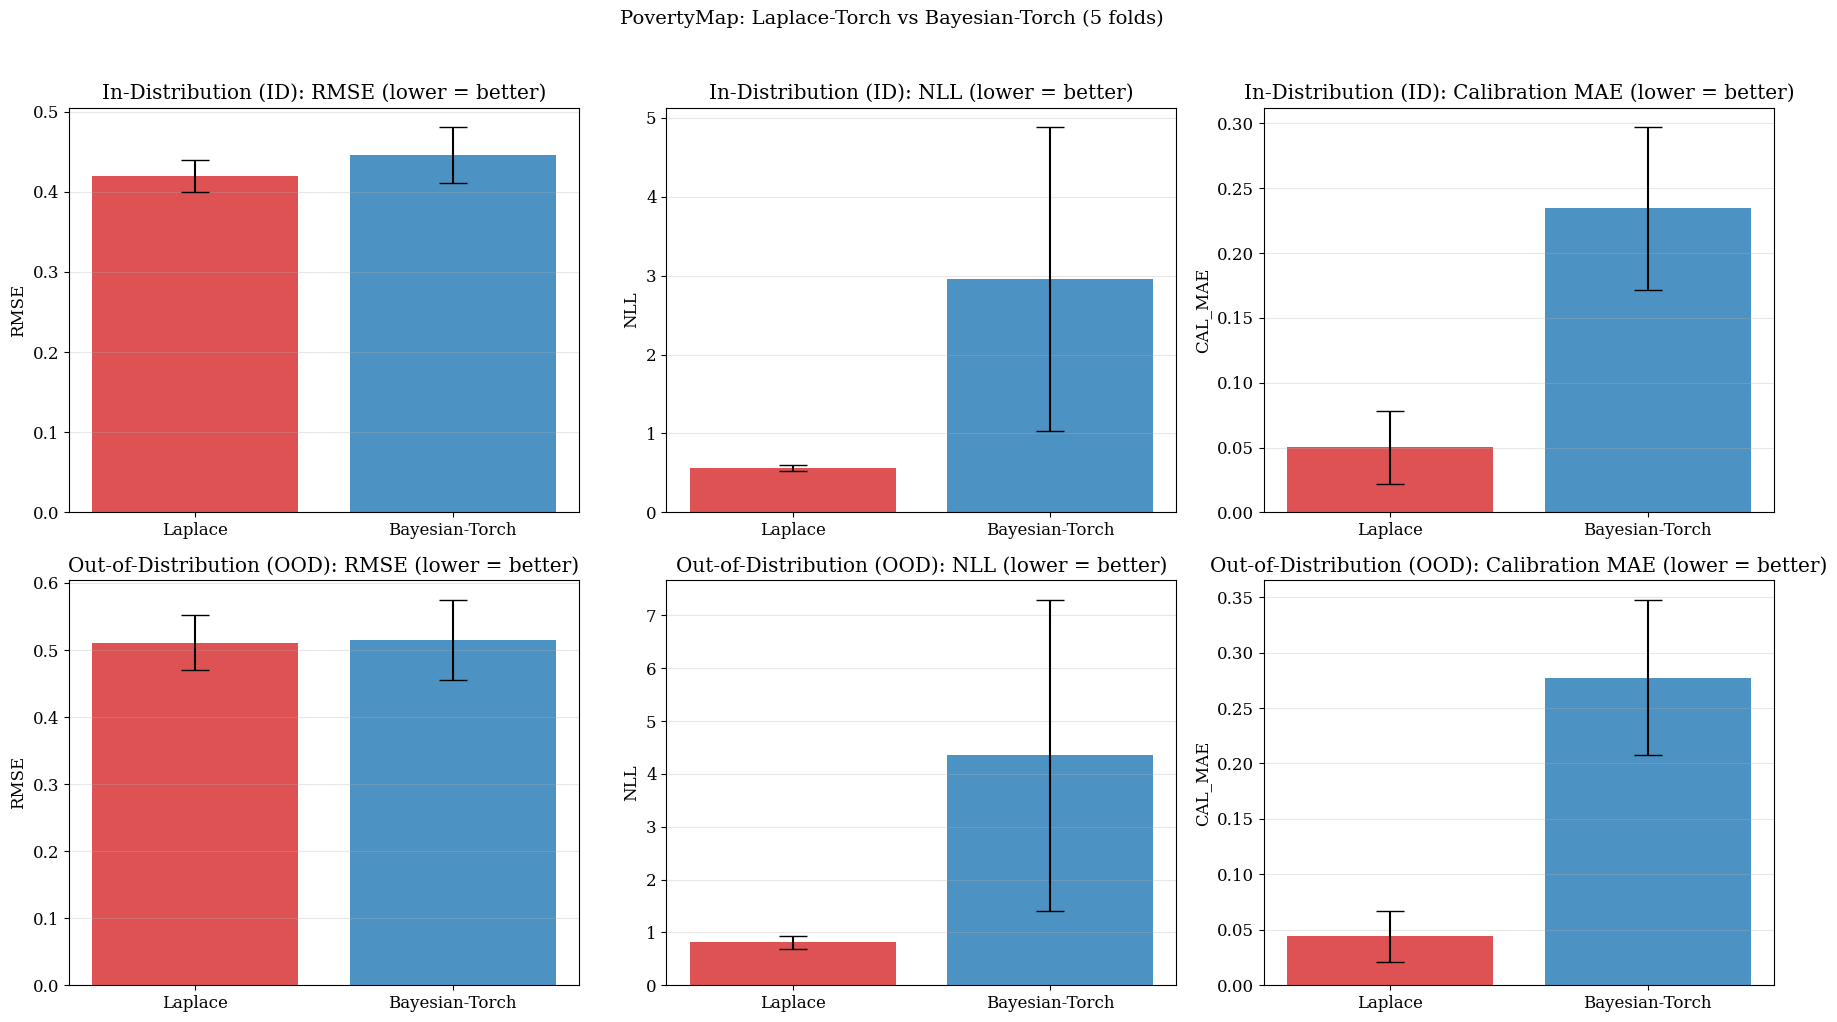

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_metrics = ['rmse', 'nll', 'cal_mae']
titles = ['RMSE (lower = better)', 'NLL (lower = better)', 'Calibration MAE (lower = better)']
colors = ['#d62728', '#1f77b4']

for row, (split_name, split_label) in enumerate(zip(['id_test', 'test'], ['In-Distribution (ID)', 'Out-of-Distribution (OOD)'])):
    for col, (metric, title) in enumerate(zip(plot_metrics, titles)):
        ax = axes[row, col]
        la_vals  = all_results[split_name]['laplace'][metric]
        bt_vals  = all_results[split_name]['bayesian_torch'][metric]
        ax.bar(['Laplace', 'Bayesian-Torch'],
               [np.mean(la_vals), np.mean(bt_vals)],
               yerr=[np.std(la_vals), np.std(bt_vals)],
               capsize=10, color=colors, alpha=0.8)
        ax.set_ylabel(metric.upper())
        ax.set_title(f'{split_label}: {title}')
        ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('PovertyMap: Laplace-Torch vs Bayesian-Torch (5 folds)', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'povertymap_bar_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

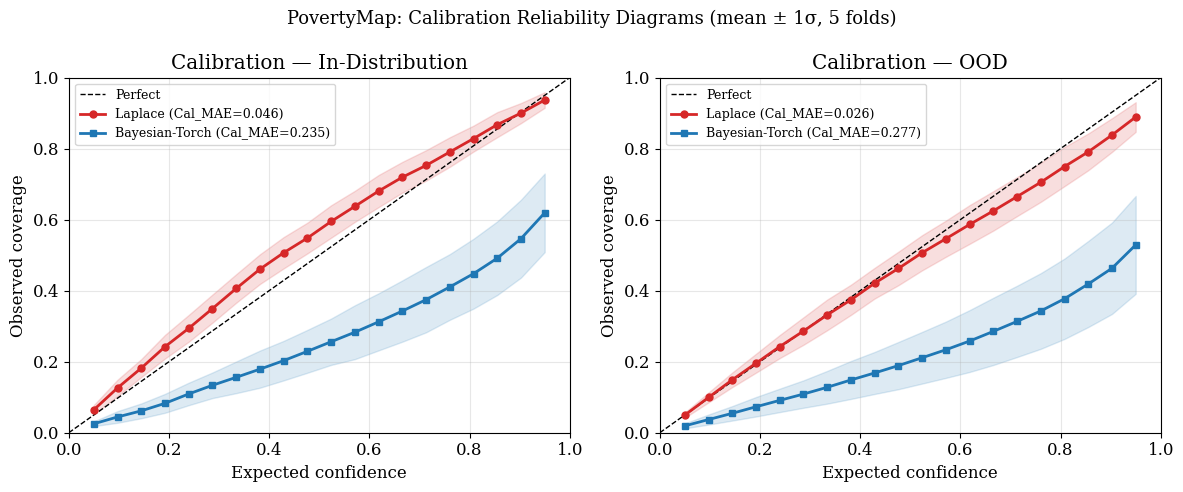

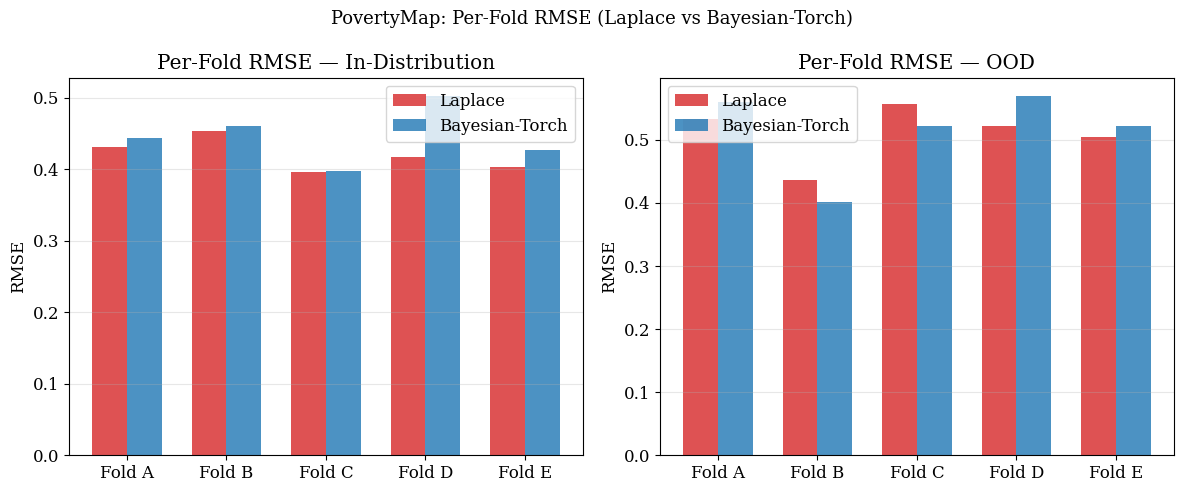

Saved figures to /u/halle/carg/home_at/Documents/BNNs/notebooks/comparison/results/figures


In [13]:
# Calibration reliability diagrams and per-fold RMSE (PovertyMap)
from scipy.stats import norm as _norm

conf_levels = np.linspace(0.05, 0.95, 20)
method_styles = {
    'laplace':        ('Laplace',        '#d62728', 'o'),
    'bayesian_torch': ('Bayesian-Torch', '#1f77b4', 's'),
}

# ── 1. Calibration reliability diagrams: per-fold curves averaged (mean ± 1σ) ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (split_name, split_label) in zip(axes, [('id_test', 'In-Distribution'), ('test', 'OOD')]):
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect')
    for method, (label, color, marker) in method_styles.items():
        curves = []
        for mu, std, y in all_raw_preds[split_name][method]:
            z_abs = np.abs((y - mu) / np.clip(std, 1e-12, None))
            curves.append([float(np.mean(z_abs <= _norm.ppf((1.0 + c) / 2.0))) for c in conf_levels])
        curves = np.array(curves)
        mean_obs = curves.mean(0)
        std_obs  = curves.std(0)
        cal_mae = float(np.mean(np.abs(mean_obs - conf_levels)))
        ax.plot(conf_levels, mean_obs, color=color, lw=2, marker=marker, ms=5,
                label=f'{label} (Cal_MAE={cal_mae:.3f})')
        ax.fill_between(conf_levels, mean_obs - std_obs, mean_obs + std_obs, color=color, alpha=0.15)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Expected confidence'); ax.set_ylabel('Observed coverage')
    ax.set_title(f'Calibration — {split_label}')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle('PovertyMap: Calibration Reliability Diagrams (mean ± 1σ, 5 folds)', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'povertymap_calibration_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Per-fold RMSE comparison ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(FOLDS))
width = 0.35
for ax, (split_name, split_label) in zip(axes, [('id_test', 'In-Distribution'), ('test', 'OOD')]):
    la_rmse = [all_full_metrics[split_name]['laplace'][i]['RMSE'] for i in range(len(FOLDS))]
    bt_rmse = [all_full_metrics[split_name]['bayesian_torch'][i]['RMSE'] for i in range(len(FOLDS))]
    ax.bar(x - width/2, la_rmse, width, label='Laplace', color='#d62728', alpha=0.8)
    ax.bar(x + width/2, bt_rmse, width, label='Bayesian-Torch', color='#1f77b4', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels([f'Fold {f}' for f in FOLDS])
    ax.set_ylabel('RMSE'); ax.set_title(f'Per-Fold RMSE — {split_label}')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('PovertyMap: Per-Fold RMSE (Laplace vs Bayesian-Torch)', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'povertymap_per_fold_rmse.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved figures to {FIGURES_DIR}")

In [ ]:
# Kuleshov et al. (2018) Eq. 3 one-sided regression calibration error —
# matches Laplace Redux's actual get_calib_regression, computed per fold from
# already-stored predictions (all_raw_preds). No retraining needed.
print("Kuleshov (2018) one-sided regression calibration error, per method/split (mean \u00b1 std across 5 folds):\n")

kuleshov_results = {split: {} for split in ['id_test', 'test']}
for split_name, split_label in [('id_test', 'ID'), ('test', 'OOD')]:
    for method, mname in [('map', 'MAP'), ('laplace', 'Laplace'), ('bayesian_torch', 'Bayesian-Torch')]:
        fold_vals = [compute_kuleshov_calibration(y, mu, std)
                     for mu, std, y in all_raw_preds[split_name][method]]
        kuleshov_results[split_name][method] = (float(np.mean(fold_vals)), float(np.std(fold_vals)))
        print(f"  {split_label:4s} {mname:15s}: {np.mean(fold_vals):.4f} \u00b1 {np.std(fold_vals):.4f}")
